# Predictive vs Causal Model
are all predictive models causal model as well?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn import set_config

set_config(transform_output="pandas")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%config InlineBackend.figure_format = "retina"
high_contrast_colors = ["#003f5c", "#ff6e54", "#f9f871", "#2db88b", "#955196"]
milder_colors = ["#00798c", "#d1495b", "#edae49", "#52a369", "#756ab2"]

%load_ext jupyter_black
warnings.filterwarnings("ignore")

## Helper Functions

In [2]:
def generate_customer_data(n):
    np.random.seed(42)
    customer_ids = np.arange(n)
    age = np.random.randint(18, 51, size=n)
    gender = np.random.choice(["male", "female", "female"], size=n)
    urban_loc = np.random.choice([0, 1], size=n)
    min_age, max_age = age.min(), age.max()
    normalized_age = (age - min_age) / (max_age - min_age)
    # Create probability that decreases with age
    # Base probability around 0.4, with younger people having 50% higher chance
    base_prob = 0.4
    age_factor = 1.5 - normalized_age  # 1.5 for youngest, 0.5 for oldest
    # Calculate probabilities
    probabilities = base_prob * age_factor
    # Ensure probabilities are within [0, 1]
    probabilities = np.clip(probabilities, 0, 1)
    # Generate app install decisions based on probabilities
    app_user = np.random.binomial(1, probabilities, size=n)
    base_clv = (
        age_factor * 50 + (gender == "female") * 50 + urban_loc * 25 + app_user * 40
    )
    cac = base_clv * 0.5 + np.random.normal(
        0, base_clv.mean() * 0.01, size=n
    )  # Customer Acquisition Cost
    # Add some noise to make it more realistic
    noise = np.random.normal(0, base_clv.mean() * 0.02, size=n)  # 10% noise
    clv_365 = base_clv + noise

    # Create DataFrame
    df = pd.DataFrame(
        {
            "customer_id": customer_ids,
            "age": age,
            "gender": gender,
            "urban_loc": urban_loc,
            "app_user": app_user,
            "cac": np.round(cac, 2),
            "clv_365": np.round(clv_365, 2),
        }
    )
    return df

In [3]:
def regression_model_results_plot(y_test, y_pred):
    # plot actual vs predicted as on ax[0] and residules on ax[1]
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].scatter(y_test, y_pred, alpha=0.3, color=high_contrast_colors[0])
    ax[0].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color=high_contrast_colors[1],
        linestyle="--",
    )
    ax[0].set_xlabel("Actual CLV")
    ax[0].set_ylabel("Predicted CLV")
    ax[0].set_title("Actual vs Predicted CLV")
    residuals = y_test - y_pred
    # residuals vs predictions plot on ax[1] as scatter plot with zero line
    sns.scatterplot(
        x=y_pred,
        y=residuals,
        ax=ax[1],
        color=high_contrast_colors[0],
        alpha=0.3,
    )
    ax[1].axhline(0, color=high_contrast_colors[1], linestyle="--", linewidth=2)
    ax[1].set_xlim(y_pred.min(), y_pred.max())
    ax[1].set_ylim(residuals.min(), residuals.max())

    ax[1].set_xlabel("Predicted CLV")
    ax[1].set_ylabel("Residuals (Actual - Predicted)")
    ax[1].set_title("Prediction Errors (Residuals)")

    ax[0].grid(alpha=0.3)
    ax[1].grid(alpha=0.3)
    sns.despine()
    # Add "phantom" annotations far to the left/right
    # fig.text(-0.1, 0.5, "")  # left padding
    # fig.text(1.1, 0.5, "")  # right padding
    # plt.savefig("my_chart.png", bbox_inches="tight", pad_inches=1.2, dpi=100)
    plt.tight_layout()
    plt.show()

In [4]:
def prep_data_for_regression(df, target_col):
    """
    Prepares data for regression by separating features and target variable.
    """

    X = df.drop(columns=[target_col, "customer_id"])
    # Encode categorical variables
    categorical_cols = X.select_dtypes(include=["object"]).columns
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)
    return X_train, X_test, y_train, y_test

In [5]:
def plot_clv_difference(df, title="CLV by App Usage"):
    df.groupby("app_user")["clv_365"].mean().plot(
        kind="bar",
        color=[high_contrast_colors[0], high_contrast_colors[1]],
        title=title,
        ylabel="Mean CLV",
        xlabel="App User Status",
        figsize=(8, 5),
        alpha=0.8,
        rot=0,
        legend=False,
    )
    # add a difference block to show the difference
    app_user_mean = df.query("app_user == 1")["clv_365"].mean()
    non_app_user_mean = df.query("app_user == 0")["clv_365"].mean()
    difference = app_user_mean - non_app_user_mean
    plt.fill_between(
        x=[0.25, 0.75],
        y1=non_app_user_mean,
        y2=app_user_mean,
        color=high_contrast_colors[3],
        alpha=0.8,
        # label=f"Difference: {difference:.2f}",
    )
    plt.annotate(
        f"Difference: {difference:.2f}",
        xy=(0.5, (app_user_mean + non_app_user_mean) / 2),
        ha="center",
        va="center",
        fontsize=12,
        color="black",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
    )
    plt.xticks([0, 1], ["Non-App User", "App User"])
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.grid(alpha=0.3)
    sns.despine()
    plt.show()

## Data for simulations

In [6]:
df = generate_customer_data(5000)
df.head()

,customer_id,age,gender,urban_loc,app_user,cac,clv_365
0,0,46,male,0,0,15.55,32.48
1,1,32,female,0,0,52.35,104.17
2,2,25,female,1,1,90.33,178.90
3,3,38,female,0,1,66.81,135.26
4,4,36,female,1,0,61.42,123.14


In [7]:
df["clv_365"].describe()

count    5000.000000
mean      111.448884
std        38.014732
min        20.550000
25%        85.085000
50%       111.615000
75%       139.622500
max       195.110000
Name: clv_365, dtype: float64

<Axes: ylabel='Density'>

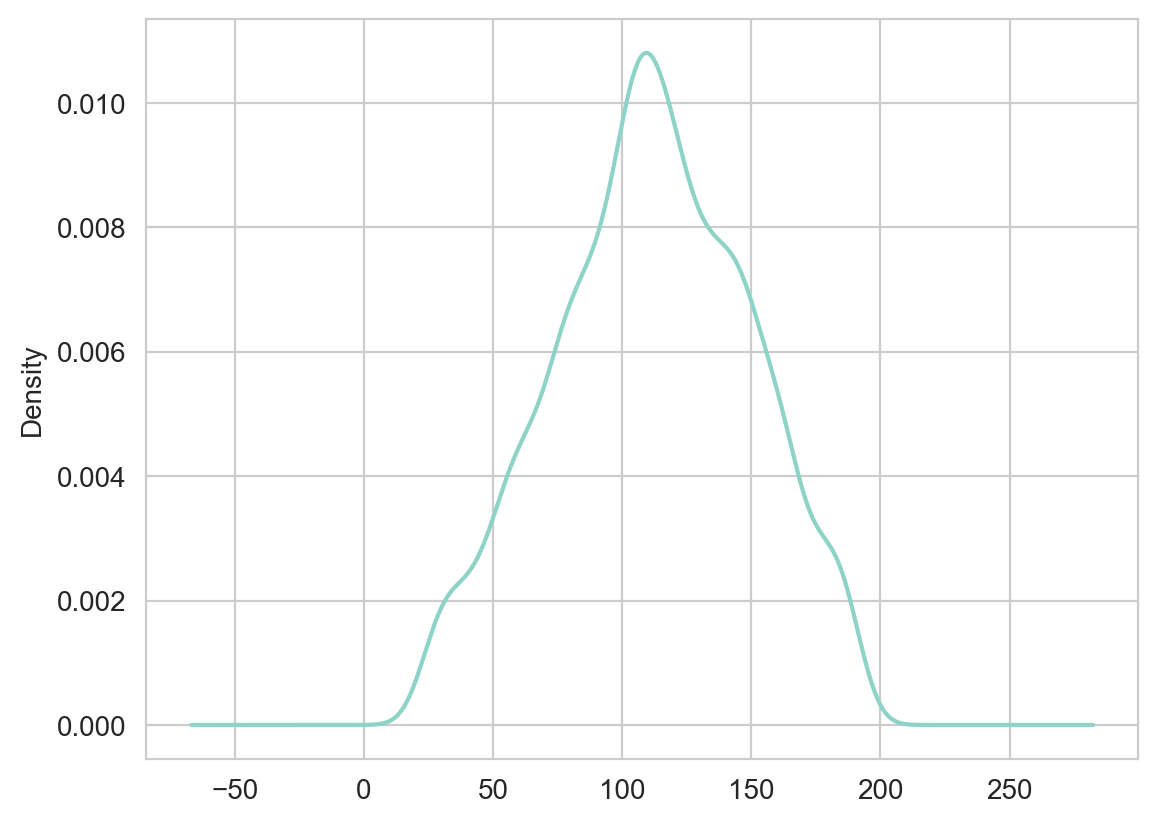

In [8]:
df["clv_365"].plot.kde()

## CAC vs CLV
"correlation does not imply causation"

In [9]:
df_cac = df[["customer_id", "cac", "clv_365"]].copy()
df_cac.head()

,customer_id,cac,clv_365
0,0,15.55,32.48
1,1,52.35,104.17
2,2,90.33,178.90
3,3,66.81,135.26
4,4,61.42,123.14


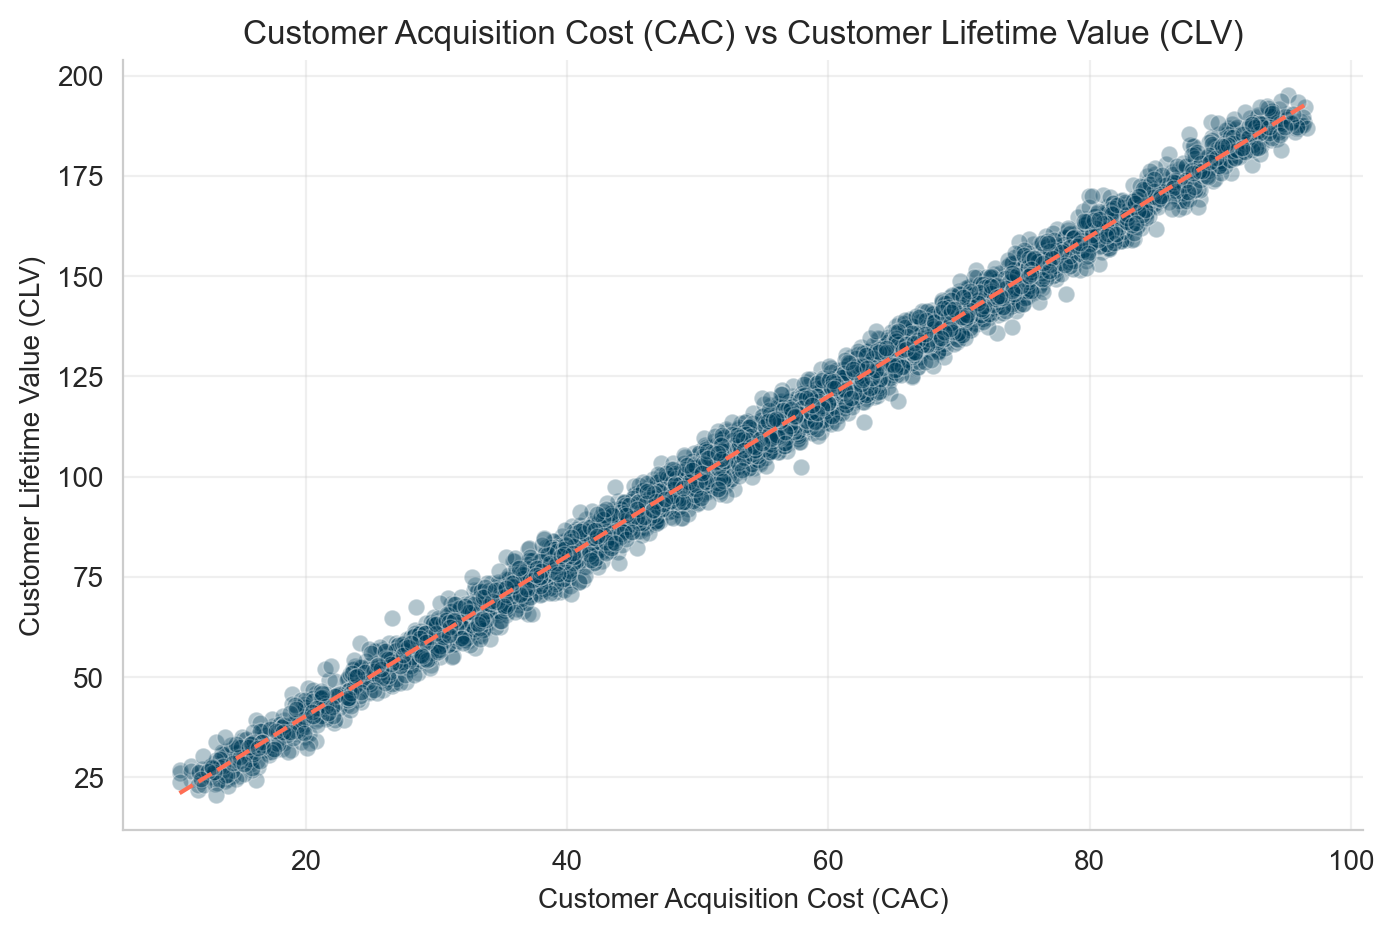

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=df_cac, x="cac", y="clv_365", color=high_contrast_colors[0], alpha=0.3, ax=ax
)
sns.regplot(
    data=df_cac,
    x="cac",
    y="clv_365",
    scatter=False,
    color=high_contrast_colors[1],
    line_kws={"color": high_contrast_colors[1], "lw": 1.5, "ls": "--"},
    ax=ax,
)

ax.set_title("Customer Acquisition Cost (CAC) vs Customer Lifetime Value (CLV)")
ax.set_xlabel("Customer Acquisition Cost (CAC)")
ax.set_ylabel("Customer Lifetime Value (CLV)")

ax.grid(alpha=0.3)
sns.despine()

plt.savefig("my_chart.png", bbox_inches="tight", pad_inches=0.8, dpi=100)
plt.show()

In [11]:
X_train, X_test, y_train, y_test = prep_data_for_regression(df_cac, "clv_365")
# Train a linear regression model
model_1 = LinearRegression()
model_1.fit(X_train, y_train)
y_pred = model_1.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 9.94
R-squared: 0.99


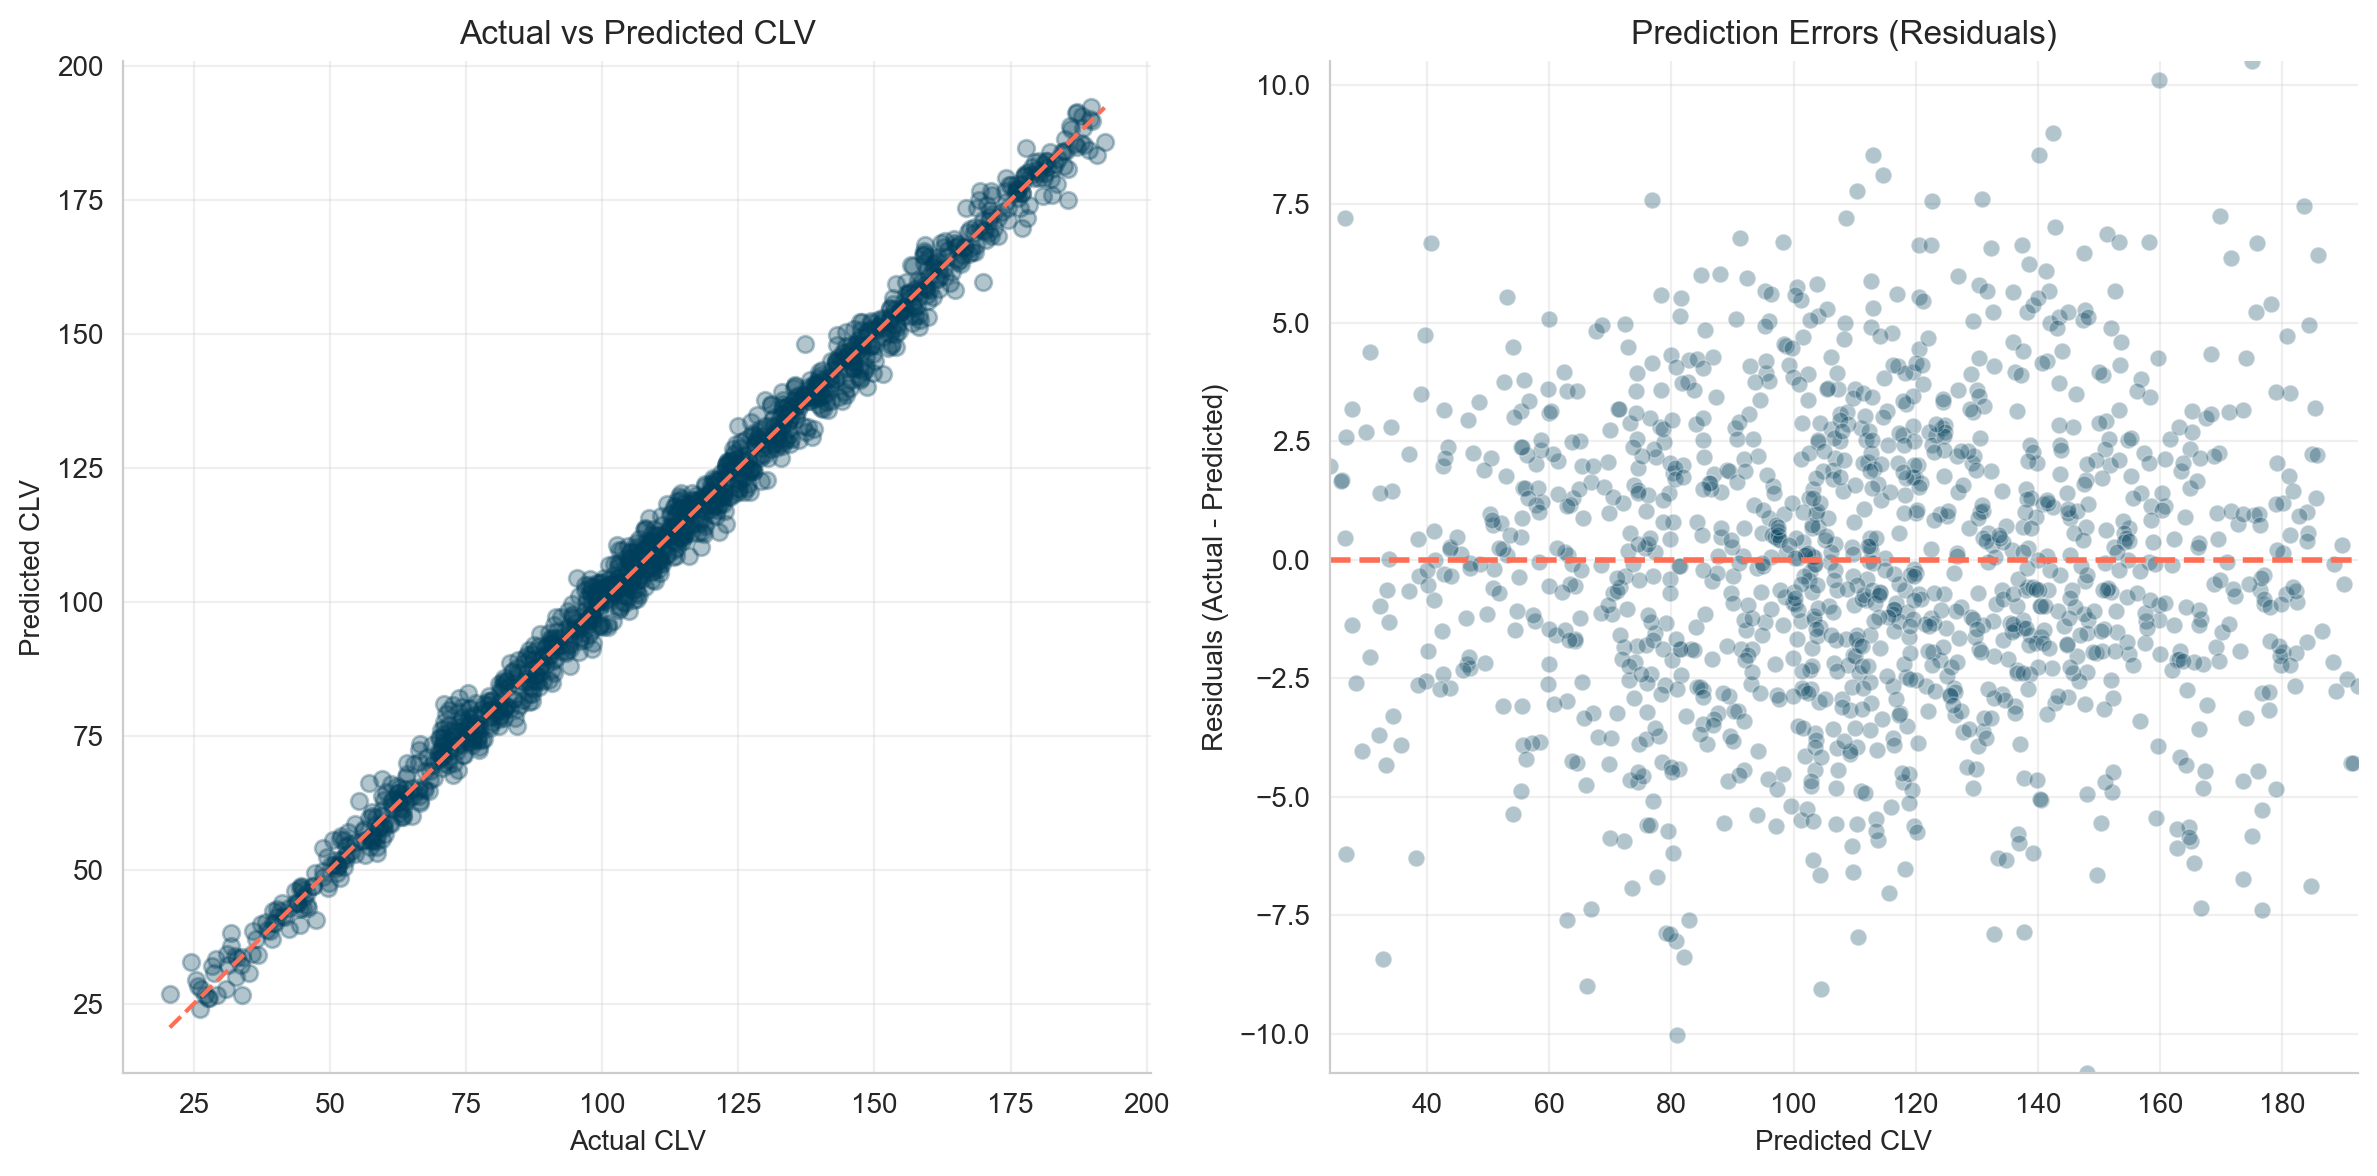

In [12]:
regression_model_results_plot(
    y_test=y_test,
    y_pred=y_pred,
)

## Other Data About Our Customers

In [13]:
df_customers = df[["customer_id", "age", "gender", "urban_loc", "app_user", "clv_365"]]
df_customers.head()

,customer_id,age,gender,urban_loc,app_user,clv_365
0,0,46,male,0,0,32.48
1,1,32,female,0,0,104.17
2,2,25,female,1,1,178.90
3,3,38,female,0,1,135.26
4,4,36,female,1,0,123.14


In [14]:
X_train, X_test, y_train, y_test = prep_data_for_regression(df_customers, "clv_365")
# Train a linear regression model
model_2 = LinearRegression()
model_2.fit(X_train, y_train)
y_pred = model_2.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 4.62
R-squared: 1.00


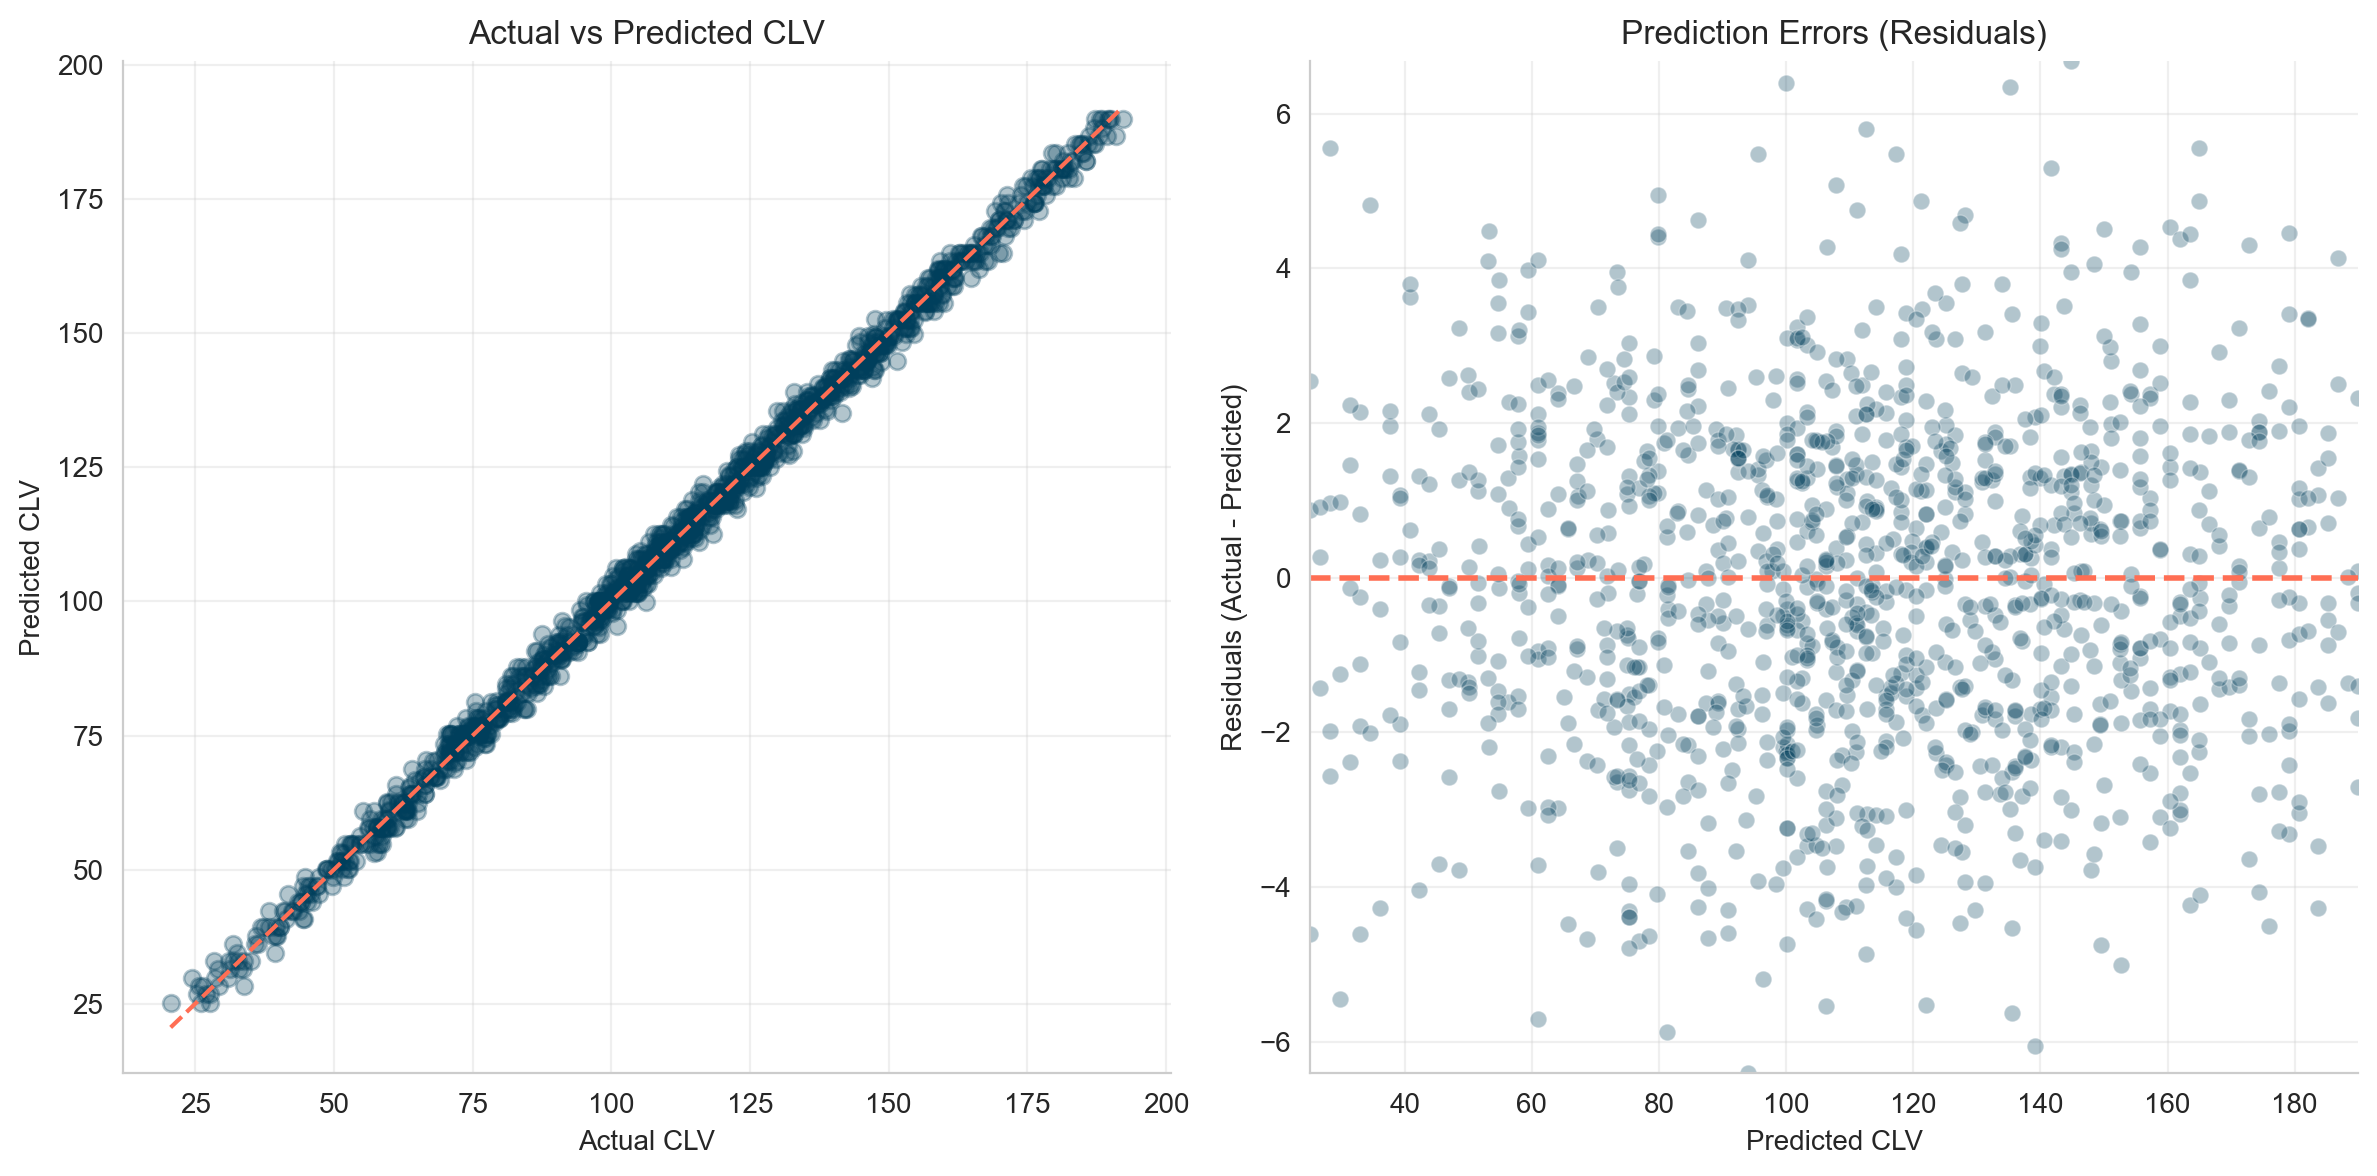

In [15]:
# Plot the results
regression_model_results_plot(
    y_test=y_test,
    y_pred=y_pred,
)

In [16]:
model_2.feature_names_in_

array(['age', 'gender', 'urban_loc', 'app_user'], dtype=object)

In [17]:
# Feature Importance
importance = pd.DataFrame(
    {
        "Feature": model_2.feature_names_in_,
        "Importance": model_2.coef_,
    }
).sort_values(by="Importance", ascending=False)
importance  # .to_markdown()

,Feature,Importance
3,app_user,19.556784
2,urban_loc,12.431565
0,age,-14.769087
1,gender,-23.758111


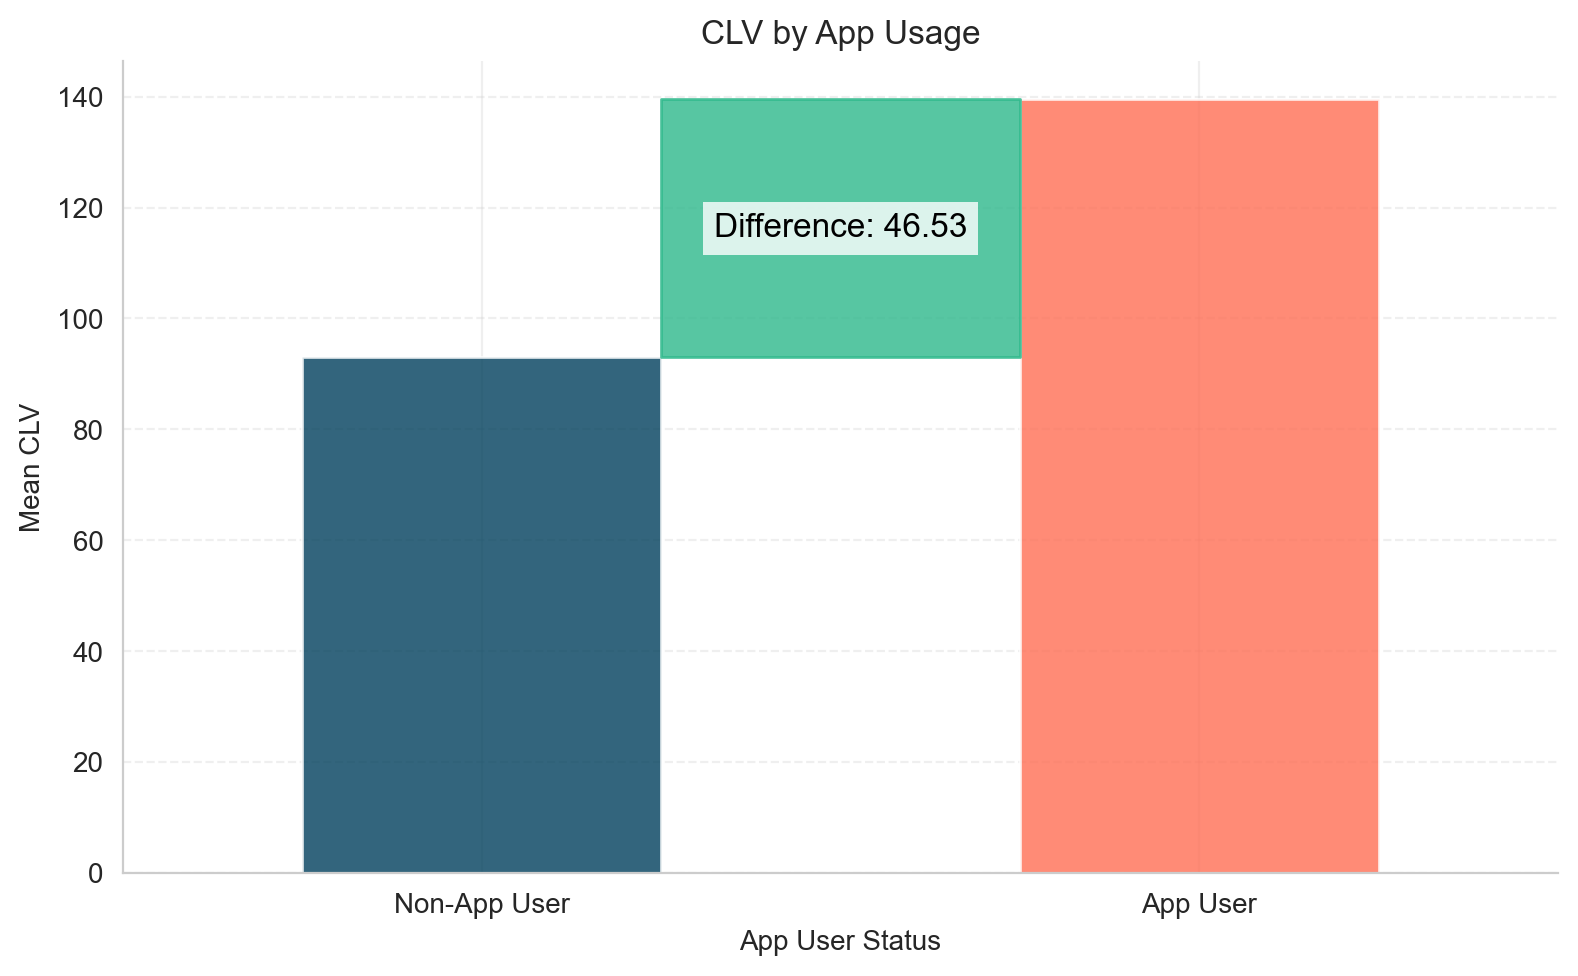

In [18]:
plot_clv_difference(df_customers)

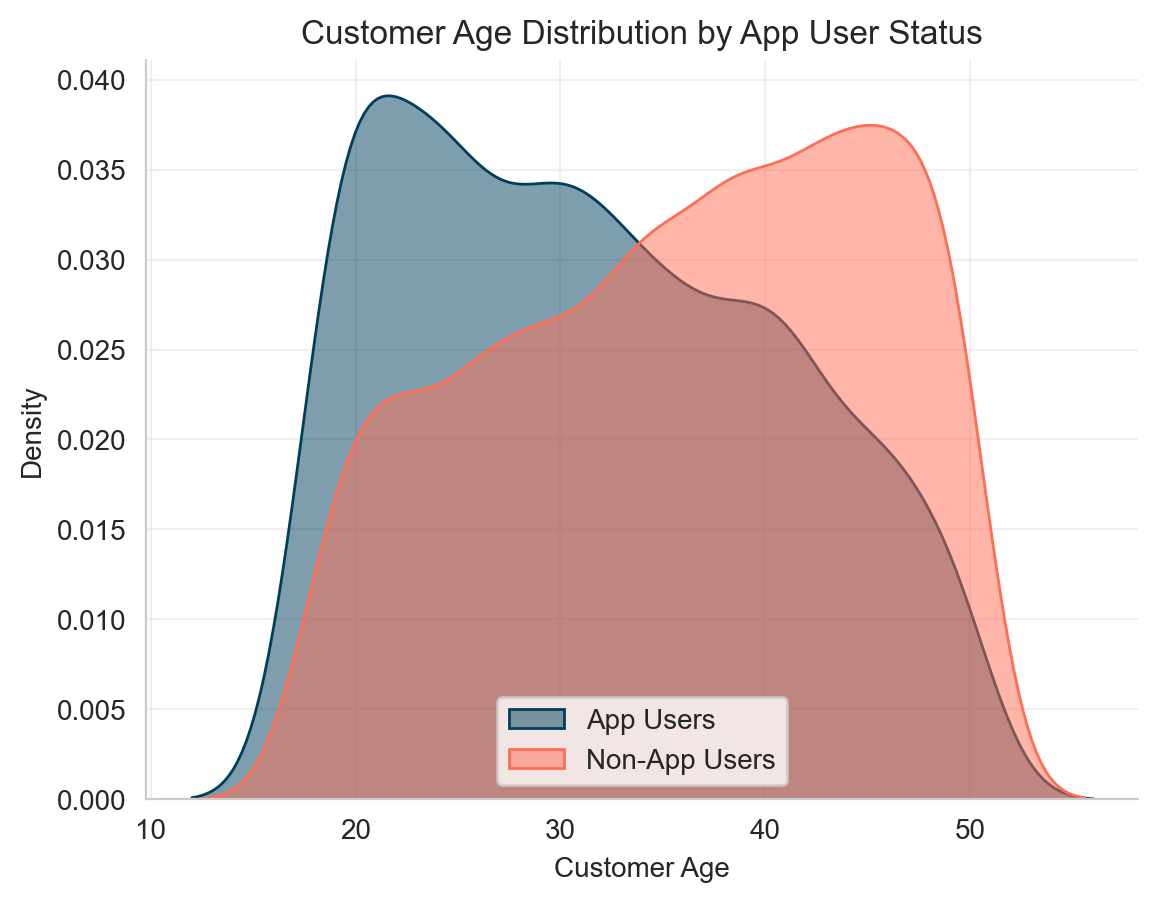

In [19]:
# kdeplot for app users
sns.kdeplot(
    df.query("app_user == 1")["age"],
    label="App Users",
    color=high_contrast_colors[0],
    fill=True,
    alpha=0.5,
)
# kdeplot for non-app users
sns.kdeplot(
    df.query("app_user == 0")["age"],
    label="Non-App Users",
    color=high_contrast_colors[1],
    fill=True,
    alpha=0.5,
)
plt.title("Customer Age Distribution by App User Status")
plt.xlabel("Customer Age")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
sns.despine()
plt.show()

In [20]:
df_customers.head()

,customer_id,age,gender,urban_loc,app_user,clv_365
0,0,46,male,0,0,32.48
1,1,32,female,0,0,104.17
2,2,25,female,1,1,178.90
3,3,38,female,0,1,135.26
4,4,36,female,1,0,123.14


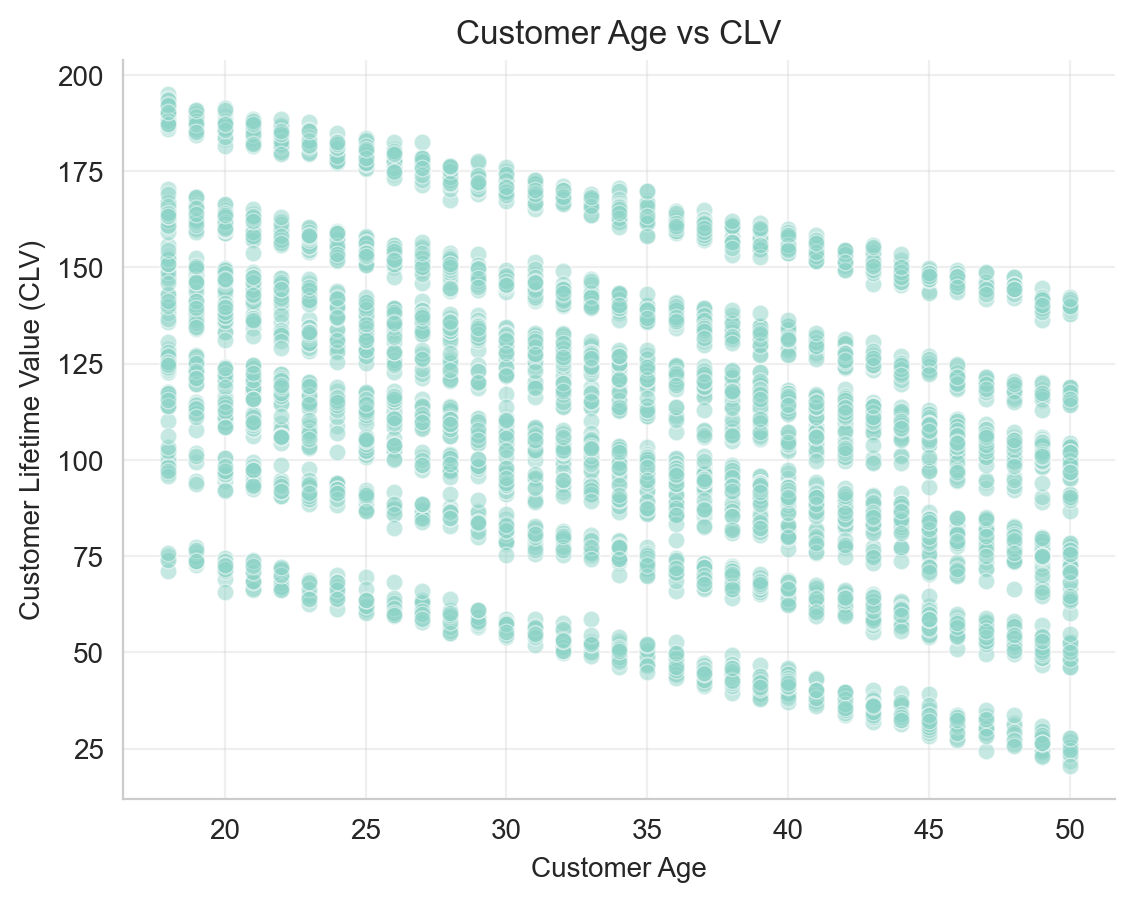

In [21]:
sns.scatterplot(
    data=df_customers,
    x="age",
    y="clv_365",
    # hue="app_user",
    palette=[high_contrast_colors[0], high_contrast_colors[1]],
    alpha=0.5,
)
plt.title("Customer Age vs CLV")
plt.xlabel("Customer Age")
plt.ylabel("Customer Lifetime Value (CLV)")
plt.grid(alpha=0.3)
sns.despine()
plt.show()

In [22]:
X_train, X_test, y_train, y_test = prep_data_for_regression(df_customers, "clv_365")
model_3 = RandomForestRegressor(n_estimators=500, random_state=42)
model_3.fit(X_train, y_train)
y_pred = model_3.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

Root Mean Squared Error: 2.22
R-squared: 1.00


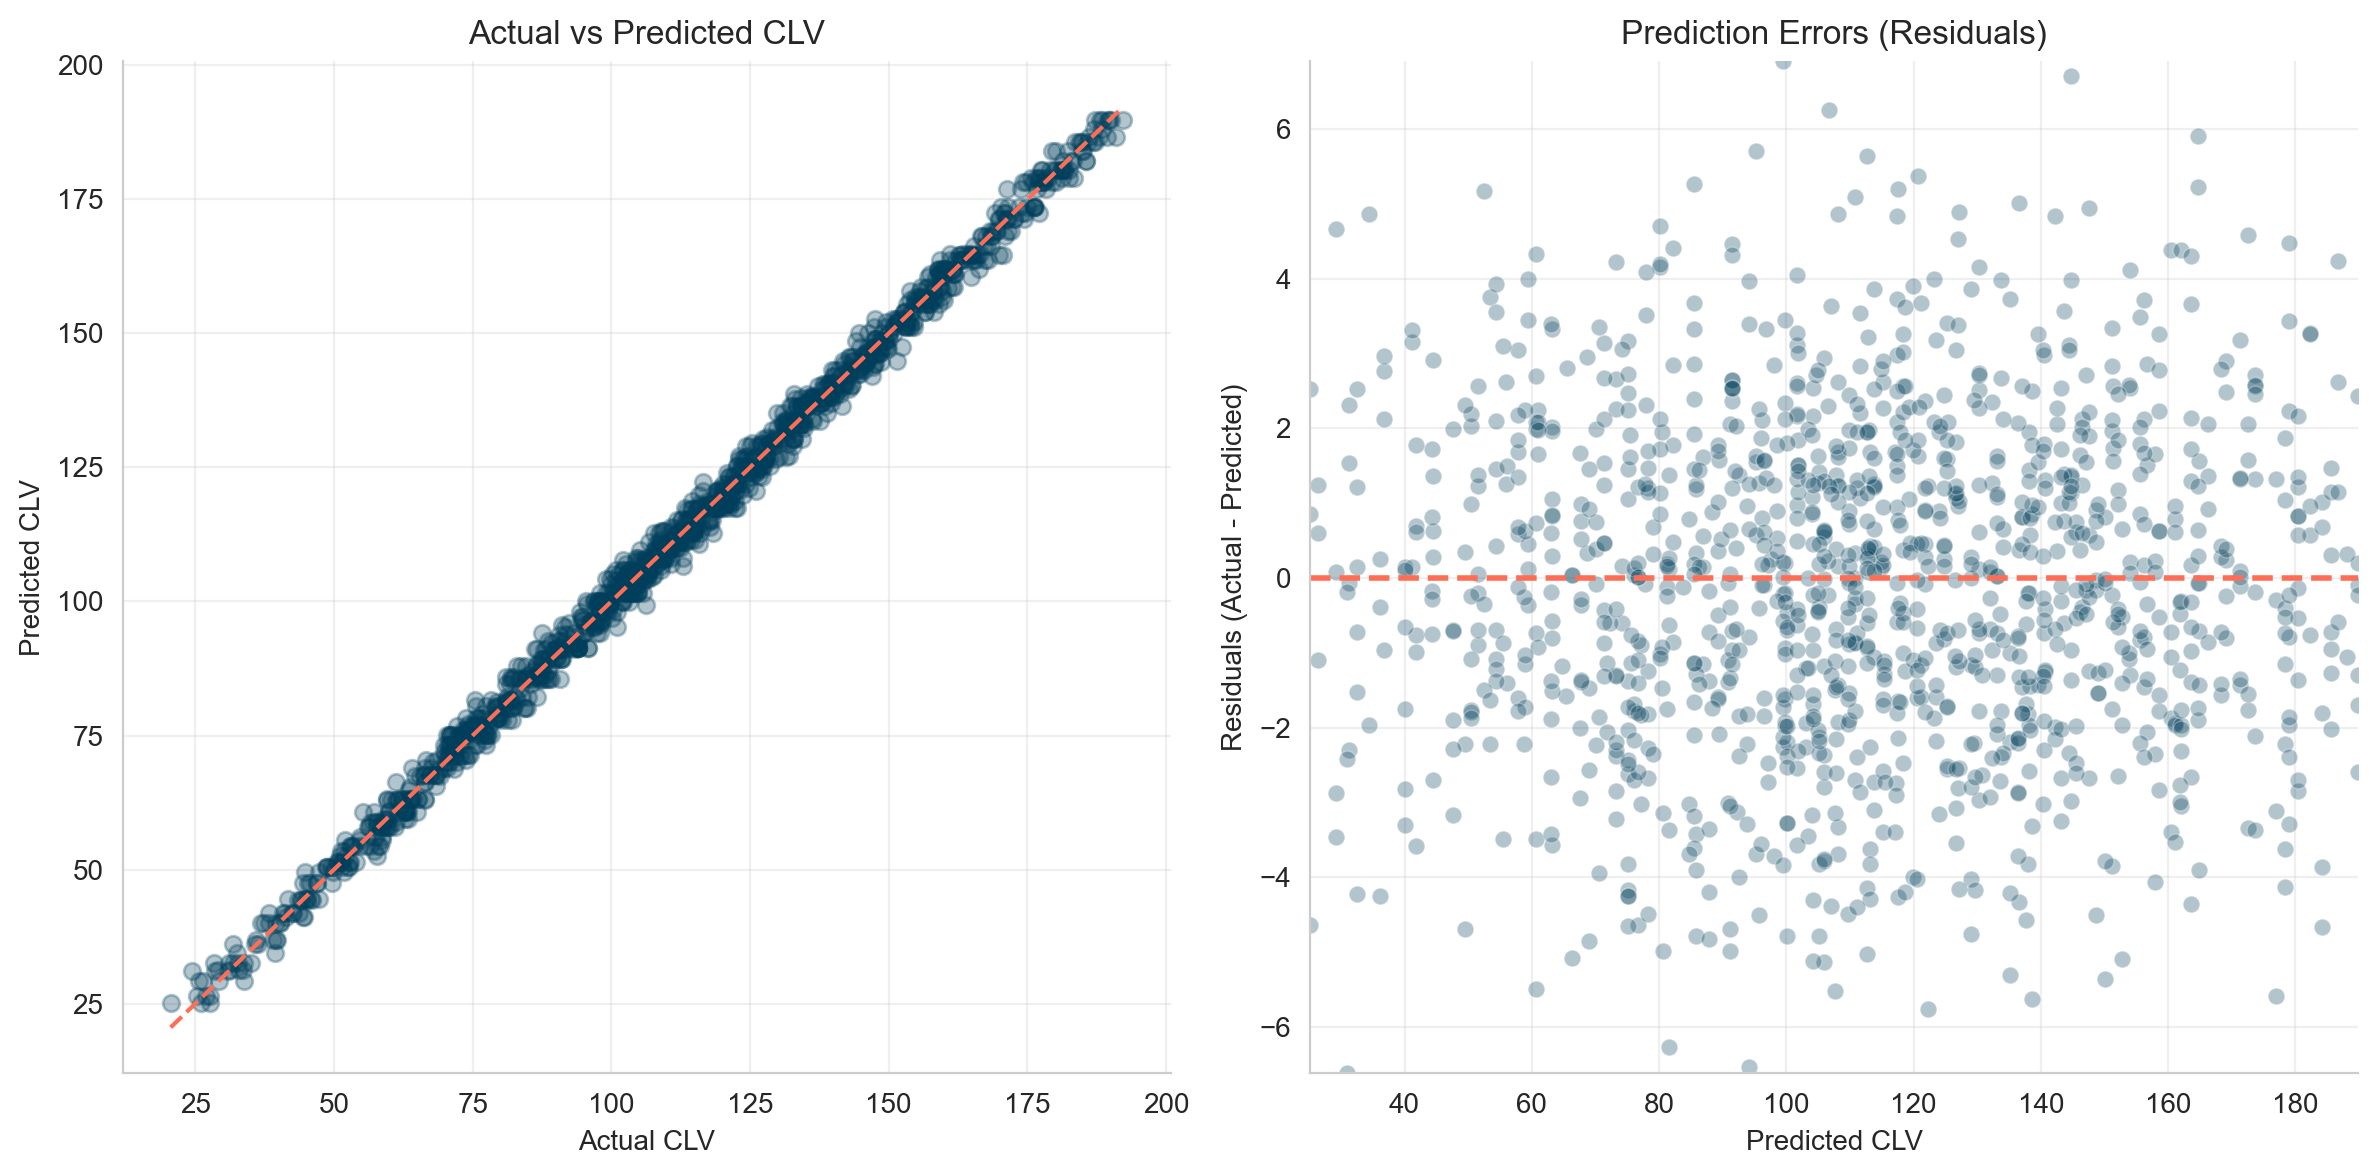

In [23]:
regression_model_results_plot(
    y_test=y_test,
    y_pred=y_pred,
)

In [24]:
X_all = pd.concat([X_train, X_test], axis=0)
y_all = pd.concat([y_train, y_test], axis=0)
model_3.fit(X_all, y_all)
# X_all treated
X_all["app_user"] = 1  # Set all customers to treatment (app user)
y_pred_treated = model_3.predict(X_all)
# X_all control
X_all["app_user"] = 0  # Set all customers to control (non-app user)
y_pred_control = model_3.predict(X_all)
# Calculate the treatment effect
df_customers_analysis = df_customers.copy()
df_customers_analysis["clv_if_all_app_users"] = y_pred_treated.round(2)
df_customers_analysis["clv_if_all_non_app_users"] = y_pred_control.round(2)
df_customers_analysis["treatment_effect"] = (
    df_customers_analysis["clv_if_all_app_users"]
    - df_customers_analysis["clv_if_all_non_app_users"]
)
df_customers_analysis.head()

,customer_id,age,gender,urban_loc,app_user,clv_365,clv_if_all_app_users,clv_if_all_non_app_users,treatment_effect
0,0,46,male,0,0,32.48,137.27,96.48,40.79
1,1,32,female,0,0,104.17,176.62,135.78,40.84
2,2,25,female,1,1,178.90,179.02,138.48,40.54
3,3,38,female,0,1,135.26,66.96,26.41,40.55
4,4,36,female,1,0,123.14,154.23,113.94,40.29


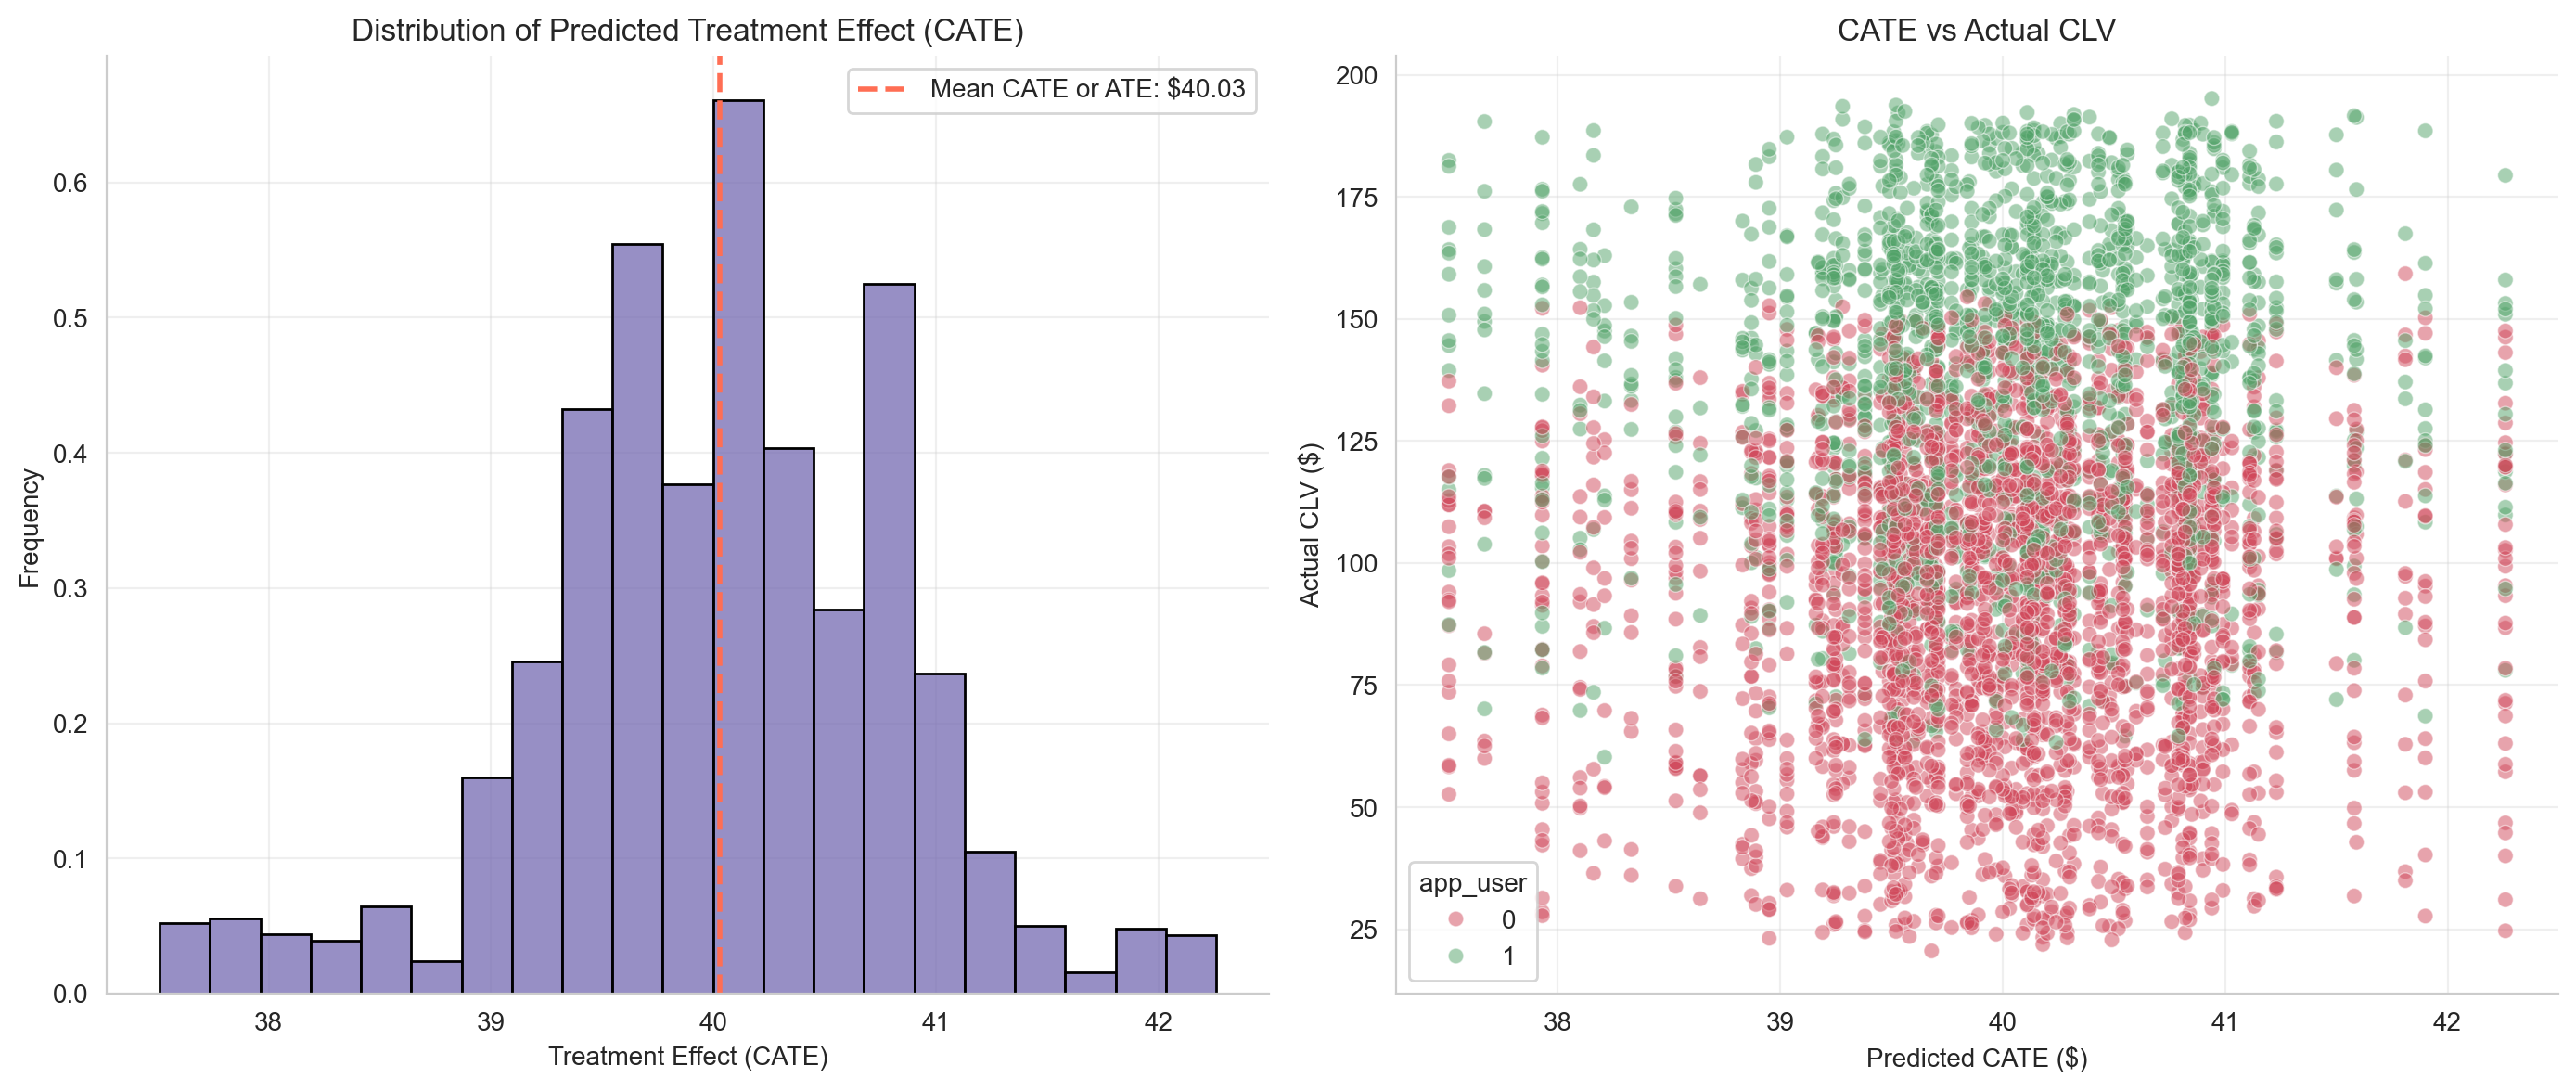

In [25]:
# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. CATE distribution
sns.histplot(
    df_customers_analysis["treatment_effect"],
    bins=21,
    ax=axes[0],
    color=milder_colors[4],
    # kde=True,
    stat="density",
    edgecolor="black",
)
axes[0].set_title("Distribution of Predicted Treatment Effect (CATE)")
axes[0].set_xlabel("Treatment Effect (CATE)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(
    df_customers_analysis["treatment_effect"].mean(),
    color=high_contrast_colors[1],
    linestyle="--",
    linewidth=2,
    label=f'Mean CATE or ATE: ${df_customers_analysis["treatment_effect"].mean():.2f}',
)
axes[0].legend()
axes[0].grid(alpha=0.3)

# 4. CATE vs actual treatment effect
sns.scatterplot(
    x=df_customers_analysis["treatment_effect"],
    y=df_customers_analysis["clv_365"],
    ax=axes[1],
    hue=df_customers_analysis["app_user"],
    palette=[milder_colors[1], milder_colors[3]],
    alpha=0.5,
)
axes[1].set_title("CATE vs Actual CLV")
axes[1].set_xlabel("Predicted CATE ($)")
axes[1].set_ylabel("Actual CLV ($)")
axes[1].grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()